In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from tensorflow.keras.datasets import cifar10

In [3]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 38s 0us/step


In [5]:
x_train.shape

(50000, 32, 32, 3)

In [7]:
x_train[0].shape

(32, 32, 3)

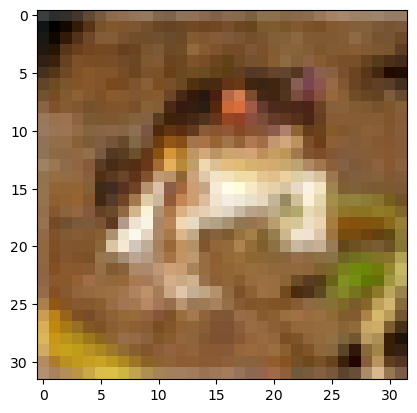

In [8]:
plt.imshow(x_train[0])

In [9]:
x_train.max()

np.uint8(255)

In [10]:
x_train = x_train/255

In [11]:
x_test = x_test/255

In [12]:
x_test.shape

(10000, 32, 32, 3)

In [13]:
y_train

array([[6],
       [9],
       [9],
       ...,
       [9],
       [1],
       [1]], shape=(50000, 1), dtype=uint8)

In [14]:
from tensorflow.keras.utils import to_categorical

In [16]:
y_cat_train = to_categorical(y_train, 10)

In [17]:
y_cat_test = to_categorical(y_test, 10)

In [18]:
y_train[0]

array([6], dtype=uint8)

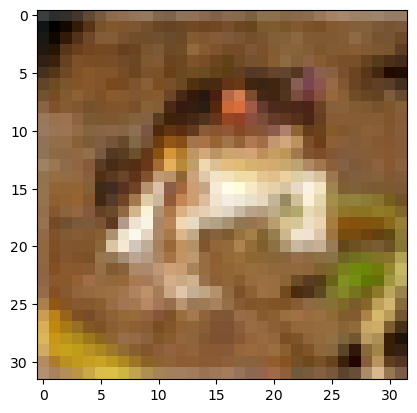

In [20]:
plt.imshow(x_train[0])

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten

In [24]:
model = Sequential()

model.add(Conv2D(filters = 32, kernel_size = (4,4), input_shape = (32,32,3), activation='relu'))

model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(filters = 32, kernel_size = (4,4), input_shape = (32,32,3), activation='relu'))

model.add(MaxPool2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(256, activation='relu'))

model.add(Dense(10, activation='softmax'))

model.compile(loss = 'categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

In [25]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 29, 29, 32)     │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 32)     │        16,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       205,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,610 (881.29 KB)

 Trainable params: 225,610 (881.29 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
from tensorflow.keras.callbacks import EarlyStopping

In [27]:
early_stop = EarlyStopping(monitor = 'val_loss', patience = 2)

In [28]:
model.fit(x_train, y_cat_train, epochs=15, validation_data=(x_test, y_cat_test), callbacks=[early_stop])

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.4573 - loss: 1.5041 - val_accuracy: 0.5438 - val_loss: 1.2666
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.5804 - loss: 1.1810 - val_accuracy: 0.5895 - val_loss: 1.1554
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.6305 - loss: 1.0487 - val_accuracy: 0.6365 - val_loss: 1.0211
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.6670 - loss: 0.9491 - val_accuracy: 0.6366 - val_loss: 1.0336
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.7002 - loss: 0.8558 - val_accuracy: 0.6613 - val_loss: 0.9590
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.7250 - loss: 0.7813 - val_accuracy: 0.6739 - val_loss: 0.9664
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.7493 - loss: 0.7146 - val_accuracy: 0.6732 - val_loss: 0.9617


In [29]:
metrics = pd.DataFrame(model.history.history)

In [30]:
metrics

,accuracy,loss,val_accuracy,val_loss
0,0.45728,1.504146,0.5438,1.266600
1,0.58040,1.180953,0.5895,1.155428
2,0.63048,1.048685,0.6365,1.021073
3,0.66704,0.949082,0.6366,1.033586
4,0.70016,0.855808,0.6613,0.958993
5,0.72496,0.781332,0.6739,0.966446
6,0.74926,0.714616,0.6732,0.961712


In [31]:
metrics.columns

Index(['accuracy', 'loss', 'val_accuracy', 'val_loss'], dtype='object')

<Axes: >

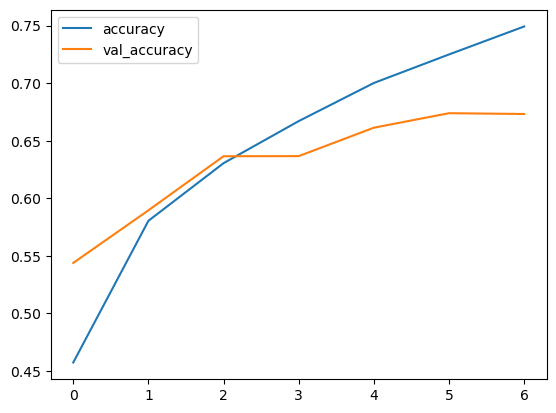

In [32]:
metrics[['accuracy', 'val_accuracy']].plot()

<Axes: >

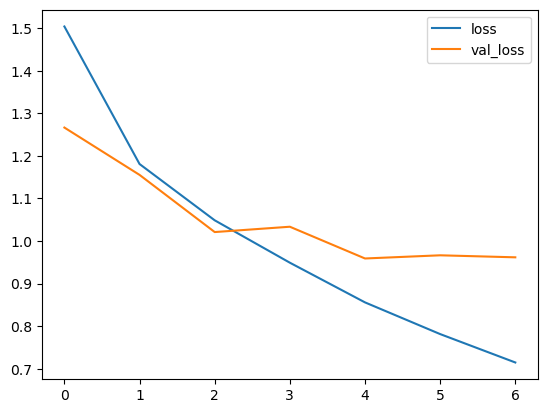

In [33]:
metrics[['loss', 'val_loss']].plot()

In [34]:
model.evaluate(x_test, y_cat_test, verbose = 0)

[0.961712121963501, 0.6732000112533569]

In [35]:
from sklearn.metrics import classification_report, confusion_matrix

In [42]:
probabilities = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [44]:
predictions = np.argmax(probabilities, axis = 1)

In [45]:
print(classification_report(predictions, y_test))

              precision    recall  f1-score   support

           0       0.74      0.70      0.72      1050
           1       0.75      0.86      0.81       873
           2       0.65      0.51      0.57      1258
           3       0.54      0.46      0.50      1175
           4       0.56      0.68      0.61       821
           5       0.52      0.59      0.56       884
           6       0.74      0.75      0.75       981
           7       0.75      0.71      0.73      1050
           8       0.80      0.74      0.77      1081
           9       0.69      0.83      0.75       827

    accuracy                           0.67     10000
   macro avg       0.67      0.68      0.68     10000
weighted avg       0.67      0.67      0.67     10000



In [46]:
confusion_matrix(predictions, y_test)

array([[736,  40,  68,  22,  24,  13,   8,  17,  61,  61],
       [ 15, 754,   2,   6,   5,   0,   4,   1,  24,  62],
       [ 52,  22, 645,  99, 164,  77,  99,  49,  23,  28],
       [ 28,  17,  80, 543,  80, 227,  74,  61,  33,  32],
       [ 13,  12,  52,  59, 555,  39,  31,  49,   2,   9],
       [  8,   6,  53, 154,  35, 524,  22,  55,  15,  12],
       [  7,  18,  36,  54,  59,  34, 740,   9,   5,  19],
       [ 10,  13,  43,  48,  59,  77,  13, 746,  12,  29],
       [108,  47,  14,   7,  18,   5,   8,   7, 804,  63],
       [ 23,  71,   7,   8,   1,   4,   1,   6,  21, 685]])

In [47]:
my_image = x_test[0]

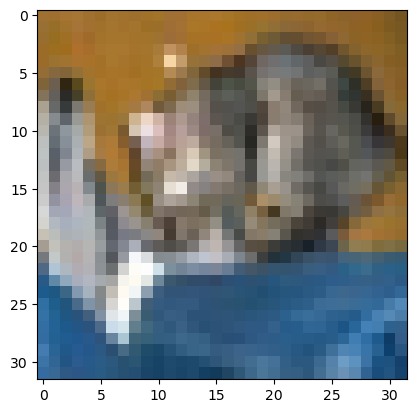

In [48]:
plt.imshow(my_image)

In [49]:
y_test[0]

array([3], dtype=uint8)

In [51]:
my_image.shape

(32, 32, 3)

In [56]:
probs = model.predict(my_image.reshape(1, 32, 32, 3))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


In [57]:
pred = np.argmax(probs, axis = 1)

In [58]:
pred

array([3])